In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [4]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/esm2_ProGym_matrices.pickle',
           'rb') as f:
    esm_dict = pickle.load(f)

In [5]:
keys = list(pg_dict.keys())

In [6]:
pg_dict[keys[6]]

{'sequence': 'MDVNPTLLFLKVPAQNAISTTFPYTGDPPYSHGTGTGYTMDTVNRTHQYSERGRWTTNTETGAPQLNPIDGPLPEDNEPSGYAQTDCVLEAMAFLEESHPGIFETSCLETMEVVQQTRVDKLTQGRQTYDWTLNRNQPAATALANTIEVFRSNGLTANESGRLIDFLKDVMESMNKEEMEITTHFQRKRRVRDNMTKKMVTQRTIGKRKQRLNKRSYLIRALTLNTMTKDAERGKLKRRAIATPGMQIRGFVYFVETLARSICEKLEQSGLPVGGNEKKAKLANVVRKMMTNSQDTEISFTITGDNTKWNENQNPRMFLAMITYITRNQPEWFRNVLSIAPIMFSNKMARLGKGYMFESKSMKIRTQIPAEMLASIDLKYFNDSTRKKIEKIRPLLIDGTASLSPGMMMGMFNMLSTVLGVSILNLGQKRHTKTTYWWDGLQSSDDFALIVNAPNHEGIQAGVNRFYRTCKLLGINMSKKKSYINRTGTFEFTSFFYRYGFVANFSMELPSFGVSGINESADMSIGVTVIKNNMINNDLGPATAQMALQLFIKDYRYTYRCHRGDTQIQTRRSFEIKKLWEQTHSKAGLLVSDGGPNLYNIRNLHIPEVCLKWELMDEDYQGRLCNPLNPFVNHKDIESVNNAVIMPAHGPAKNMEYDAVATTHSWIPKRNRSILNTSQRGILEDEQMYQKCCNLFEKFFPSSSYRRPVGISSMVEAMVSRARIDARIDFESGRIKKEEFTEIMKICSTIEELRRQK',
 'DMS': array([[-1.95880262, -1.37186639, -1.77259145, ...,         nan,
         -1.60697603, -1.52958919],
        [-1.5198612 , -1.53056148,         nan, ..., -2.3836482 ,
         -1.76541943, -0.81145049],
        [      

In [7]:
pg_sp_list=[]
esm_sp_list=[]
for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        pg_sp_list.append(pg_sp_val[0])
        esm_sp_list.append(esm_sp_val[0])

In [8]:
pg_sp_list[0]

np.float64(0.3791506937886044)

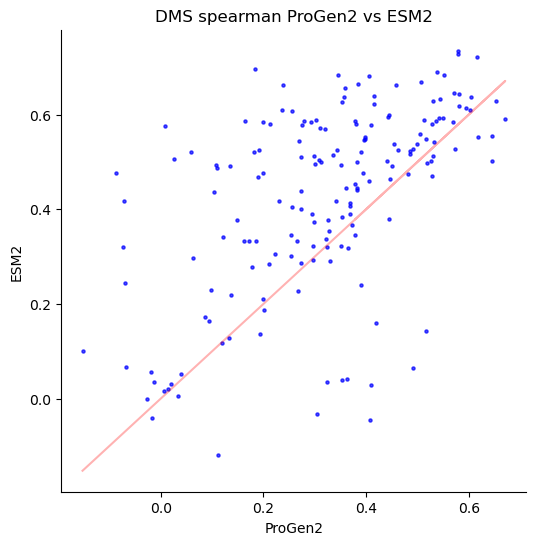

In [10]:
x = pg_sp_list
y = esm_sp_list

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='blue', alpha=0.7, s=5)
plt.plot(x, x, color='red', alpha=0.3)
plt.xlabel("ProGen2")
plt.ylabel("ESM2")
plt.title(f"DMS spearman ProGen2 vs ESM2")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"Spearman = {round(sp_val,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

In [11]:
label_list=[]

for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        label_list.append((key, pg_sp_val[0], esm_sp_val[0]))

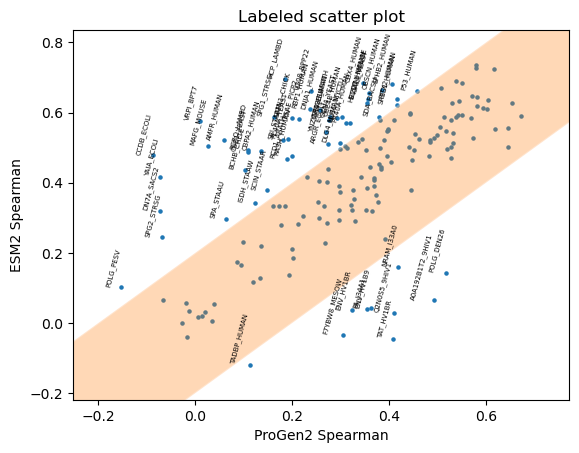

In [37]:
labels = [d[0] for d in label_list]
x1 = [d[1] for d in label_list]
y1 = [d[2] for d in label_list]

t = 0.2
w = 0.1
x_up = max(x1) + w
x_dn = min(x1) - w
y_up = max(y1) + w
y_dn = min(y1) - w

x = np.linspace(x_dn, x_up, 200)
z1 = x + t
z2 = x - t

plt.figure()
plt.scatter(x1, y1, s=5)
plt.plot(x,z1, color='white', alpha=0.3)
plt.plot(x,z2, color='white', alpha=0.3)
plt.fill_between(x, z1, z2, alpha=0.3)



for label, xi, yi in label_list:
    if xi > t+yi or yi > t+xi:
        plt.text(xi, yi, label, ha='right',
    va='bottom', rotation=75, fontsize=5)
        
plt.xlim(x_dn, x_up)   
plt.ylim(y_dn, y_up)

plt.xlabel("ProGen2 Spearman")
plt.ylabel("ESM2 Spearman")
plt.title("Labeled scatter plot")
plt.show()

In [20]:
label_list=[]

for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        label_list.append((key, pg_sp_val[0], esm_sp_val[0]))

labels = [d[0] for d in label_list]
x = [d[1] for d in label_list]
y = [d[2] for d in label_list]

t = 0.45

for label, xi, yi in label_list:
    if np.abs(xi-yi) > t:
        sequence = pg_dict[label]['sequence']
        print(label, f"Spearman delta = {xi-yi}", f"Sequence length = {len(sequence)}" )

AMFR_HUMAN Spearman delta = -0.46076637762995537 Sequence length = 47
HCP_LAMBD Spearman delta = -0.5119593522690653 Sequence length = 55
TAT_HV1BR Spearman delta = 0.45407496204306863 Sequence length = 86
CCDB_ECOLI Spearman delta = -0.5653003611532029 Sequence length = 101
VRPI_BPT7 Spearman delta = -0.5667072653626561 Sequence length = 56
MAFG_MOUSE Spearman delta = -0.47908193282093287 Sequence length = 41
YAIA_ECOLI Spearman delta = -0.48859970259243335 Sequence length = 52


In [30]:
seq_lens = []

for key in keys:
    if 'llr_matrix' in pg_dict[key].keys():
        sequence = pg_dict[key]['sequence']
        seq_lens.append(len(pg_dict[key]['sequence']))

In [33]:
np.array(seq_lens).mean()

np.float64(277.12138728323697)

In [47]:
label_list=[]

for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        label_list.append((key, pg_sp_val[0], esm_sp_val[0]))

labels = [d[0] for d in label_list]
pg = [d[1] for d in label_list]
esm = [d[2] for d in label_list]

t = 0

sp_len = []
sp_diff = []

for label, xi, yi in label_list:
    if np.abs(yi-xi) > t:
        sequence = pg_dict[label]['sequence']
        diff = yi-xi
        length = len(sequence)
        sp_len.append(length)
        sp_diff.append(diff)

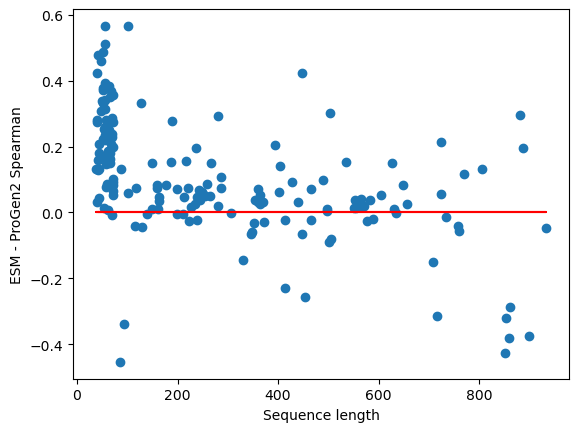

In [51]:
plt.figure()
plt.scatter(sp_len, sp_diff)
plt.plot(sp_len,np.zeros(len(sp_len)), color='red')
plt.xlabel("Sequence length")
plt.ylabel("ESM - ProGen2 Spearman")

plt.show()

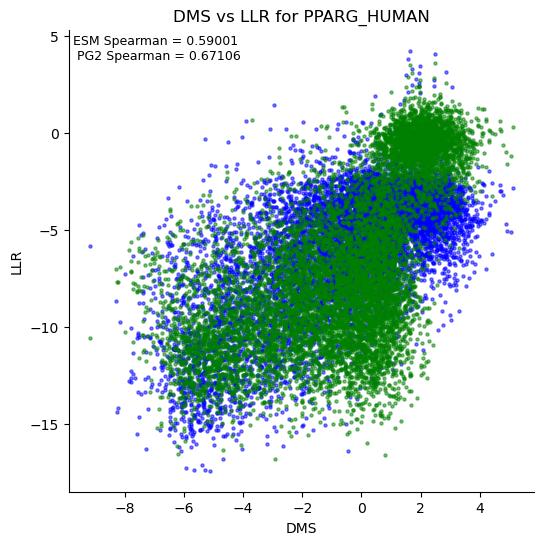

In [12]:
i = 25

x = esm_dict[keys[i]]['DMS']
y1 = esm_dict[keys[i]]['llr_matrix']
y2 = pg_dict[keys[i]]['llr_matrix']

sp_val_esm, p_val_esm = esm_dict[keys[i]]['spearman_DMS']
sp_val_pg, p_val_pg = pg_dict[keys[i]]['spearman_DMS']

mask1 = ~np.isnan(x) & ~np.isnan(y1)
x_clean = x[mask1]
y1_clean = y1[mask1]

mask2 = ~np.isnan(x) & ~np.isnan(y2)
x_clean = x[mask2]
y2_clean = y2[mask2]



# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y1_clean, color='blue', alpha=0.5, s=5)
plt.scatter(x_clean, y2_clean, color='green', alpha=0.5, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

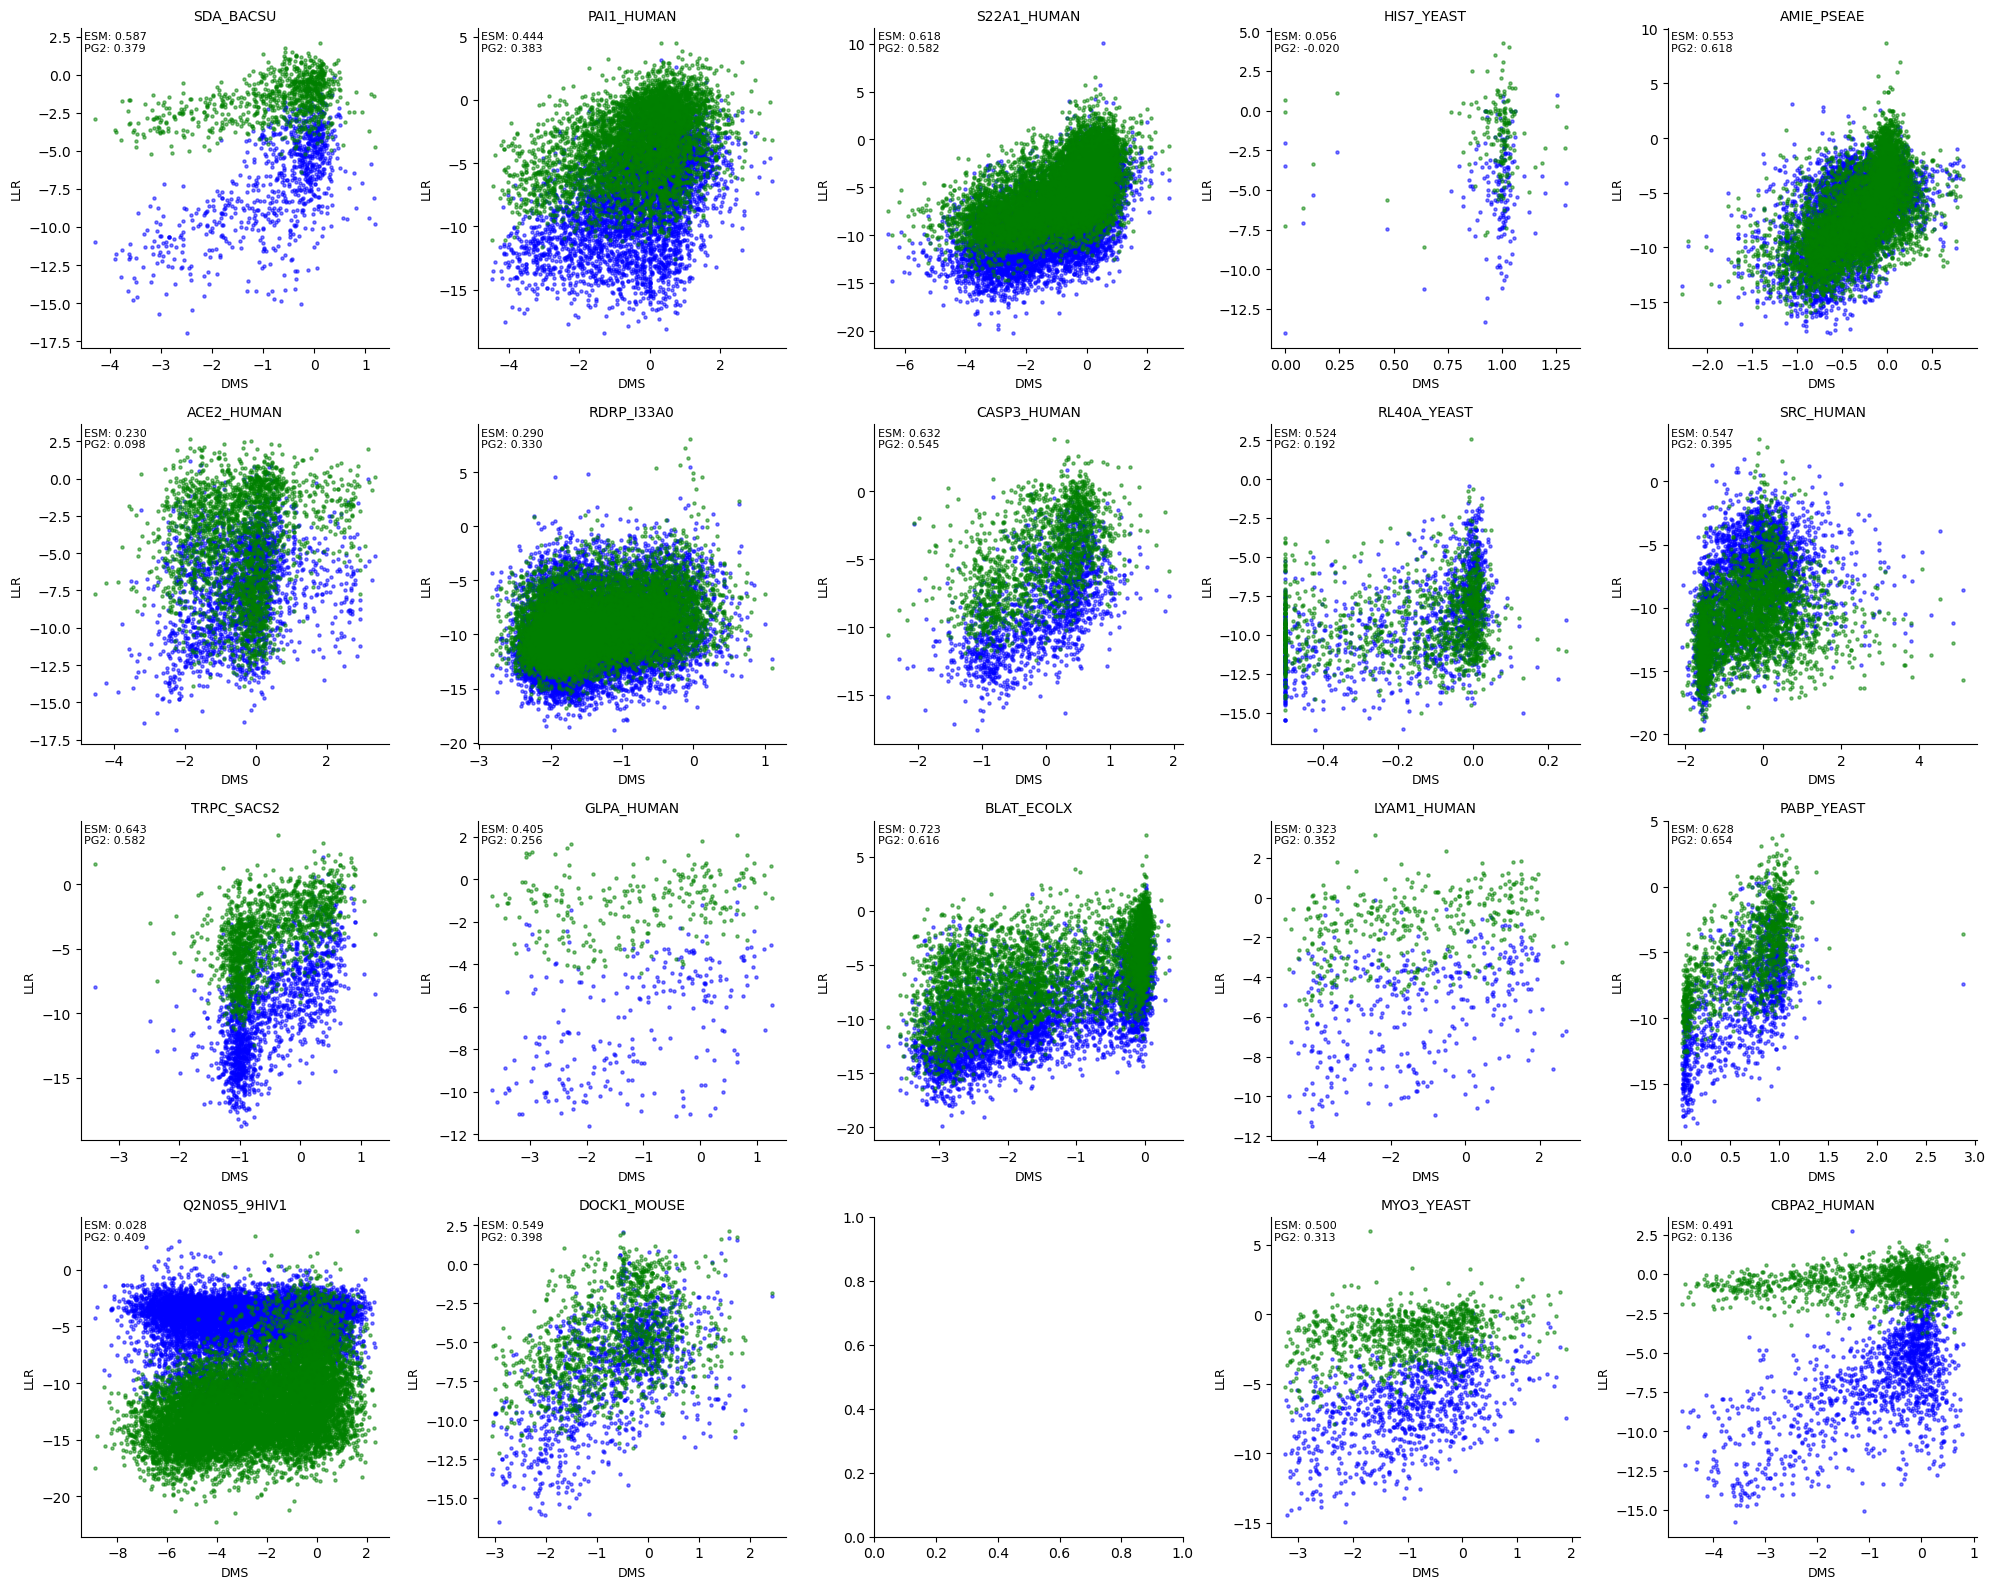

In [72]:

indices = list(range(20))  # or any 20 values of i
nrows, ncols = 4, 5

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for idx, i in enumerate(indices):
    ax = axes[idx]
    
    if 'llr_matrix' in pg_dict[keys[i]].keys():

        x = esm_dict[keys[i]]['DMS']
        y1 = esm_dict[keys[i]]['llr_matrix']
        y2 = pg_dict[keys[i]]['llr_matrix']
        
        sp_val_esm, _ = esm_dict[keys[i]]['spearman_DMS']
        sp_val_pg, _ = pg_dict[keys[i]]['spearman_DMS']
        
        # Clean NaNs
        mask1 = ~np.isnan(x) & ~np.isnan(y1)
        mask2 = ~np.isnan(x) & ~np.isnan(y2)
        
        x1_clean, y1_clean = x[mask1], y1[mask1]
        x2_clean, y2_clean = x[mask2], y2[mask2]
        
        # Scatter plots
        ax.scatter(x1_clean, y1_clean, color='blue', alpha=0.5, s=5, label='ESM')
        ax.scatter(x2_clean, y2_clean, color='green', alpha=0.5, s=5, label='PG2')
        
        # Axes labels
        ax.set_xlabel("DMS", fontsize=9)
        ax.set_ylabel("LLR", fontsize=9)
        
        # Title
        ax.set_title(keys[i], fontsize=10)
        
        # Spearman annotations
        ax.text(
            0.01, 0.99,
            f"ESM: {sp_val_esm:.3f}\nPG2: {sp_val_pg:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left'
        )
    
    # Remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Optional: grid off
    ax.grid(False)

# Adjust spacing
plt.tight_layout()
plt.show()


In [79]:
esm_sp_list = []
pg_sp_list = []

for key in pg_dict.keys():
    if 'spearman_DMS' in pg_dict[key].keys():
        esm_sp, _ = esm_dict[key]['spearman_DMS']
        pg_sp, _ = pg_dict[key]['spearman_DMS']

        esm_sp_list.append(esm_sp)
        pg_sp_list.append(pg_sp)

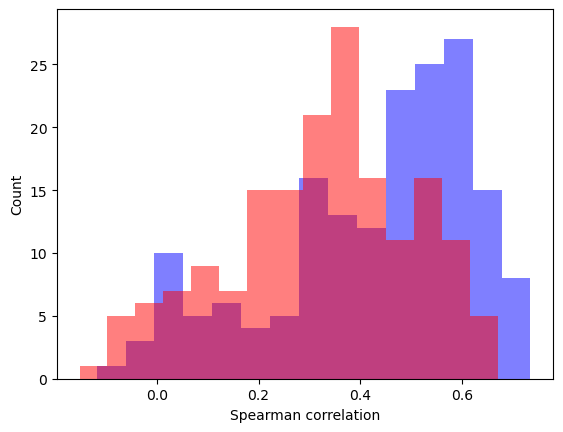

In [83]:
plt.figure()
plt.hist(esm_sp_list, bins=15, color = 'blue', alpha = 0.5)
plt.hist(pg_sp_list, bins=15, color = 'red', alpha = 0.5)
plt.xlabel("Spearman correlation")
plt.ylabel("Count")

plt.show()

In [41]:
esm_pg_sp_list=[]

for key in keys:
    if 'llr_matrix' in pg_dict[key].keys():
        esm_llr = esm_dict[key]['llr_matrix']
        pg_llr = pg_dict[key]['llr_matrix']
        sp = spearman_ignore_nan(esm_llr, pg_llr)
        esm_pg_sp_list.append((key, sp[0]))

In [40]:
esm_pg_sp_list_unzip = list(zip(*esm_pg_sp_list))

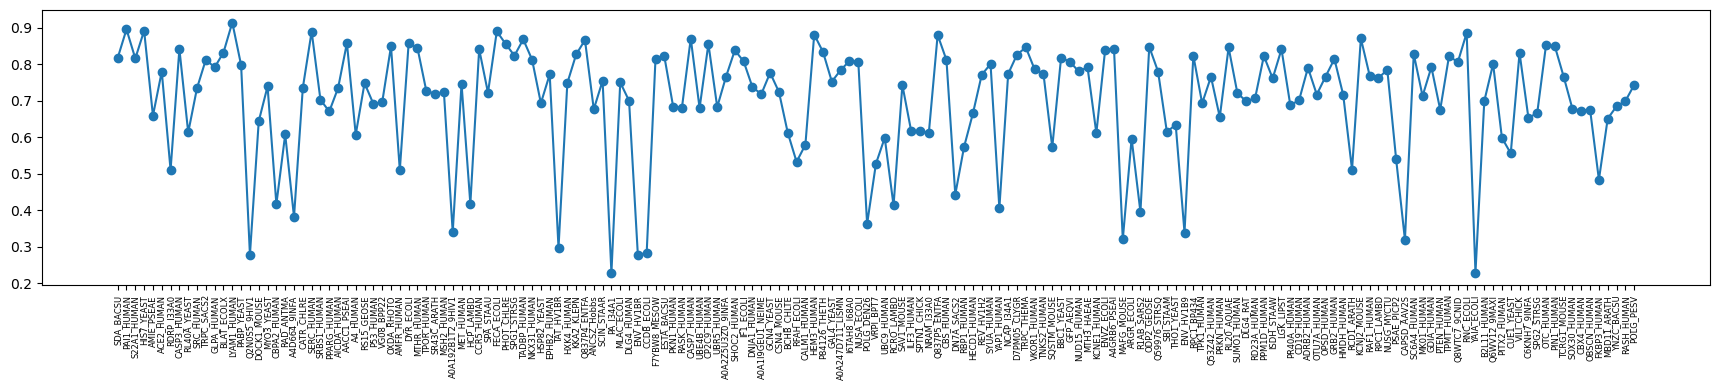

In [51]:
names = esm_pg_sp_list_unzip[0]
sp_vals = esm_pg_sp_list_unzip[1]

fig, ax = plt.subplots(
    figsize=( 0.1*len(names), 4)  # ← scale width with number of labels
)

ax.plot(sp_vals, marker='o')

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6)

fig.tight_layout()
# plt.show()

# plt.figure()
# plt.scatter(names, sp_vals)
# plt.xticks(
#     ticks=range(len(names)),
#     labels=names,
#     rotation=90,
#     fontsize=2
# )
# plt.xlabel("Spearman correlation")
# plt.ylabel("Count")

plt.show()

In [ ]:
plt.figure()
plt.scatter(sp_len, sp_diff)
plt.plot(sp_len,np.zeros(len(sp_len)), color='red')
plt.xlabel("Sequence length")
plt.ylabel("ESM - ProGen2 Spearman")

plt.show()

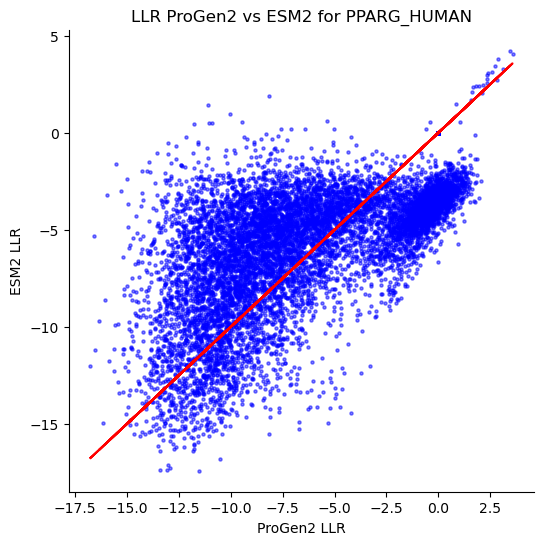

In [13]:
i = 25

x = pg_dict[keys[i]]['llr_matrix']
y = esm_dict[keys[i]]['llr_matrix']

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.5, s=5)
plt.plot(x,x,color='red')
plt.xlabel("ProGen2 LLR")
plt.ylabel("ESM2 LLR")
plt.title(f"LLR ProGen2 vs ESM2 for {keys[i]}")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

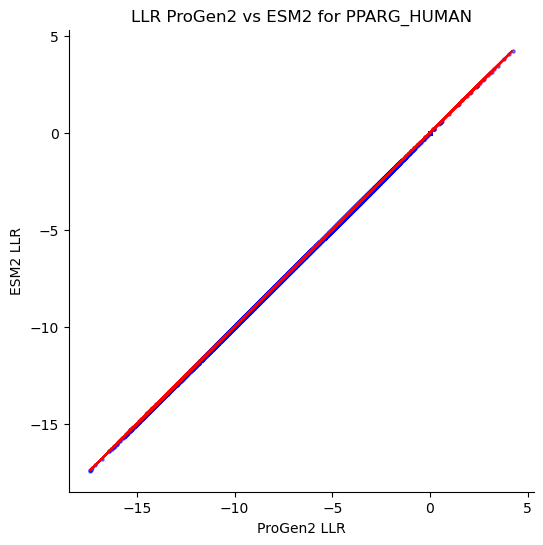

In [14]:
i = 25

x = esm_dict[keys[i]]['llr_matrix']
y = esm_dict[keys[i]]['llr_matrix']

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.5, s=5)
plt.plot(x,x,color='red')
plt.xlabel("ProGen2 LLR")
plt.ylabel("ESM2 LLR")
plt.title(f"LLR ProGen2 vs ESM2 for {keys[i]}")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()